## 8. Klassifikation

[Data Science Playlist auf YouTube](https://www.youtube.com/watch?v=VLKEj9EN2ew&list=PLLBUgWXdTBDg1Qgmwt4jKtVn9BWh5-zgy)
[![Python Data Science](https://apmonitor.com/che263/uploads/Begin_Python/DataScience08.png)](https://www.youtube.com/watch?v=VLKEj9EN2ew&list=PLLBUgWXdTBDg1Qgmwt4jKtVn9BWh5-zgy "Python Data Science")

**Klassifikation** sagt *diskrete Labels (Ergebnisse)* voraus, z. B. ``yes/no``, ``True/False`` oder eine beliebige Anzahl diskreter Stufen wie einen Buchstaben aus Texterkennung oder ein Wort aus Spracherkennung. Es gibt zwei Hauptmethoden zum Trainieren von Klassifikatoren: unüberwachtes und überwachtes Lernen. Der Unterschied ist, dass unüberwachtes Lernen keine Labels verwendet, während überwachtes Lernen Labels nutzt, um den Klassifikator aufzubauen. Das Ziel des unüberwachten Lernens ist es, Eingabe-Features zu clustern, jedoch ohne Labels zur Steuerung der Gruppierung.

![list](https://apmonitor.com/che263/uploads/Begin_Python/list.png)

### Überwachtes Lernen zur Klassifikation von Ziffern

Ein in sklearn enthaltenes Datenset umfasst 1797 Bilder von Ziffern, jeweils mit 64 Pixeln (8×8). Zu jedem Bild gibt es ein Label mit der korrekten Antwort. Ein Support-Vektor-Klassifikator wird auf der ersten Hälfte der Bilder trainiert.

In [14]:
from sklearn import datasets, svm
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
%matplotlib inline
import numpy as np

# Klassifikator trainieren
digits = datasets.load_digits()
n_samples = len(digits.images)
data = digits.images.reshape((n_samples, -1))
svc = svm.SVC(gamma=0.001)
X_train, X_test, y_train, y_test = train_test_split(
    data, digits.target, test_size=0.5, shuffle=False)
svc.fit(X_train, y_train)
print('SVC Trained')

SVC Trained


![expert](https://apmonitor.com/che263/uploads/Begin_Python/expert.png)

### Ziffernklassifikator testen

Die Bildklassifikation wird auf 10 zufällig ausgewählten Bildern aus der anderen Hälfte des Datensatzes trainiert, um das Training zu bewerten. Führe den Klassifikatortest so lange aus, bis du eine falsch klassifizierte Ziffer beobachtest.

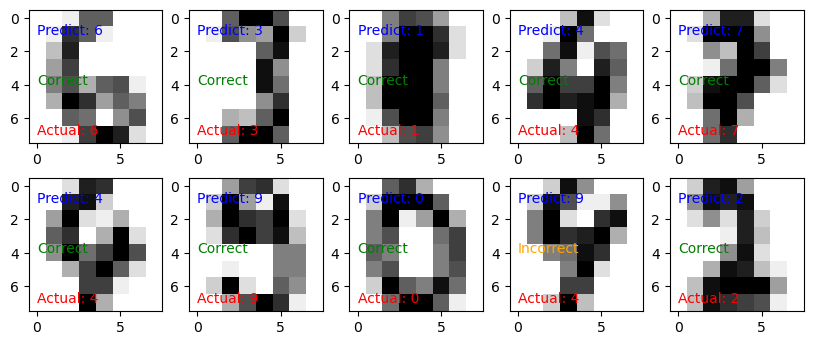

In [15]:
plt.figure(figsize=(10,4))
for i in range(10):
    n = np.random.randint(int(n_samples/2),n_samples)
    predict = svc.predict(digits.data[n:n+1])[0]
    plt.subplot(2,5,i+1)
    plt.imshow(digits.images[n], cmap=plt.cm.gray_r, interpolation='nearest')
    plt.text(0,7,'Actual: ' + str(digits.target[n]),color='r')
    plt.text(0,1,'Predict: ' + str(predict),color='b')
    if predict==digits.target[n]:
        plt.text(0,4,'Correct',color='g')
    else:
        plt.text(0,4,'Incorrect',color='orange')
plt.show()

![buildings](https://apmonitor.com/che263/uploads/Begin_Python/buildings.png)

### Klassifikation mit überwachtem Lernen

Wähle die Datensatzoption ``moons``, ``cirlces`` oder ``blobs``. Führe die folgende Zelle aus, um die Daten zu erzeugen, die zum Testen der Klassifikatoren verwendet werden.

In [18]:
option = 'moons' # moons, circles, oder blobs

n = 2000 # Anzahl der Datenpunkte
X = np.random.random((n,2))
mixing = 0.0 # Füge den Daten ein zufälliges Mischelement hinzu.
xplot = np.linspace(0,1,100)
if option=='moons':
    X, y = datasets.make_moons(n_samples=n,noise=0.1)
    yplot = xplot*0.0
elif option=='circles':
    X, y = datasets.make_circles(n_samples=n,noise=0.1,factor=0.5)
    yplot = xplot*0.0
elif option=='blobs':
    X, y = datasets.make_blobs(n_samples=n,centers=[[-5,3],[5,-3]],cluster_std=2.0)
    yplot = xplot*0.0
# Teile die Daten in Trainings- und Testteilmengen auf (jeweils 50 %).
XA, XB, yA, yB = train_test_split(X, y, test_size=0.5, shuffle=False)
# Zeige die Regressionsergebnisse in einem Diagramm.
def assess(P):
    plt.figure()
    plt.scatter(XB[P==1,0],XB[P==1,1],marker='^',color='blue',label='True')
    plt.scatter(XB[P==0,0],XB[P==0,1],marker='x',color='red',label='False')
    plt.scatter(XB[P!=yB,0],XB[P!=yB,1],marker='s',color='orange',\
                alpha=0.5,label='Incorrect')
    plt.legend()

![idea](https://apmonitor.com/che263/uploads/Begin_Python/idea.png)

### S.1 Logistische Regression (Logistic Regression)

**Definition**: Logistische Regression ist ein Machine-Learning-Algorithmus zur Klassifikation. Dabei werden die Wahrscheinlichkeiten der möglichen Ergebnisse eines einzelnen Versuchs mit einer logistischen Funktion modelliert.

**Vorteile**: Logistische Regression ist für diesen Zweck (Klassifikation) konzipiert und eignet sich besonders, um den Einfluss mehrerer unabhängiger Variablen auf eine einzelne Zielvariable zu verstehen.

**Nachteile**: Funktioniert nur, wenn die vorhergesagte Variable binär ist; setzt voraus, dass alle Prädiktoren unabhängig voneinander sind; und geht von fehlwertfreien Daten aus.

In [20]:
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression(solver='lbfgs')
lr.fit(XA,yA)
yP = lr.predict(XB)
assess(yP)

![idea](https://apmonitor.com/che263/uploads/Begin_Python/idea.png)

### S.2 Naive Bayes

**Definition**: Der Naive-Bayes-Algorithmus basiert auf dem Satz von Bayes und nimmt Unabhängigkeit zwischen jedem Merkmalspaar an. Naive-Bayes-Klassifikatoren funktionieren in vielen realen Situationen gut, z. B. bei Dokumentklassifikation und Spam-Filterung.

**Vorteile**: Dieser Algorithmus benötigt nur wenig Trainingsdaten, um die notwendigen Parameter zu schätzen. Naive-Bayes-Klassifikatoren sind im Vergleich zu anspruchsvolleren Methoden äußerst schnell.

**Nachteile**: Naive Bayes ist als schlechter Schätzer bekannt.


In [21]:
from sklearn.naive_bayes import GaussianNB
nb = GaussianNB()
nb.fit(XA,yA)
yP = nb.predict(XB)
assess(yP)

![idea](https://apmonitor.com/che263/uploads/Begin_Python/idea.png)

### S.3 Stochastischer Gradientenabstieg (Stochastic Gradient Descent)

**Definition**: Stochastischer Gradientenabstieg ist ein einfaches und sehr effizientes Verfahren zum Fitten linearer Modelle. Es ist besonders nützlich bei sehr großen Stichprobenzahlen und unterstützt verschiedene Verlustfunktionen sowie Regularisierungen für Klassifikation.

**Vorteile**: Effizienz und einfache Implementierung.

**Nachteile**: Erfordert mehrere Hyperparameter und ist empfindlich gegenüber Feature-Skalierung.




__////////Anmerkung: muss Regularisierung erklärt werden?__

In [22]:
from sklearn.linear_model import SGDClassifier
sgd = SGDClassifier(loss='modified_huber', shuffle=True,random_state=101)
sgd.fit(XA,yA)
yP = sgd.predict(XB)
assess(yP)

![idea](https://apmonitor.com/che263/uploads/Begin_Python/idea.png)

### S.4 K-nächste Nachbarn (K-Nearest Neighbours)

**Definition**: Die nachbarschaftsbasierte Klassifikation ist eine Form des lazy learning: Es wird kein allgemeines internes Modell aufgebaut, sondern lediglich die Trainingsbeispiele gespeichert. Die Klassifikation eines Punkts erfolgt per Mehrheitsabstimmung seiner k nächsten Nachbarn.

**Vorteile**: Einfach zu implementieren, robust gegenüber verrauschten Trainingsdaten und bei großen Trainingsmengen wirkungsvoll.

**Nachteile**: Der Wert ``K`` muss bestimmt werden; die Rechenkosten sind hoch, da für jede Instanz die Distanz zu allen Trainingsbeispielen berechnet werden muss. Eine mögliche Lösung zur Wahl von ``K`` ist eine Rückkopplungsschleife (z. B. Validierung), um die optimale Nachbarzahl zu ermitteln.

In [23]:
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(XA,yA)
yP = knn.predict(XB)
assess(yP)

![idea](https://apmonitor.com/che263/uploads/Begin_Python/idea.png)

### S.5 Entscheidungsbaum (Decision Tree)

**Definition**: Aus Daten mit Attributen und den zugehörigen Klassen erzeugt ein Entscheidungsbaum eine Folge von Regeln, mit denen sich die Daten klassifizieren lassen.

**Vorteile**: Entscheidungsbäume sind leicht zu verstehen und zu visualisieren, erfordern nur wenig Datenaufbereitung und können sowohl numerische als auch kategoriale Daten verarbeiten.

**Nachteile**: Entscheidungsbäume können komplexe Bäume erzeugen, die schlecht generalisieren. Sie können instabil sein, da kleine Datenänderungen zu einem völlig anderen Baum führen können.

In [24]:
from sklearn.tree import DecisionTreeClassifier
dtree = DecisionTreeClassifier(max_depth=10,random_state=101,\
                               max_features=None,min_samples_leaf=5)
dtree.fit(XA,yA)
yP = dtree.predict(XB)
assess(yP)

![idea](https://apmonitor.com/che263/uploads/Begin_Python/idea.png)

### S.6 Random Forest

**Definition**: Ein Random-Forest-Klassifikator ist ein Meta-Schätzer, der eine Vielzahl von Entscheidungsbäumen auf unterschiedlichen Teilstichproben eines Datensatzes trainiert und deren Ergebnisse mittelt, um die Vorhersagegenauigkeit des Modells zu verbessern und Überanpassung (Overfitting) zu kontrollieren.
Die Größe der Teilstichproben entspricht dabei immer der Größe des ursprünglichen Datensatzes, jedoch werden die Stichproben mit Zurücklegen gezogen.

**Vorteile**: Verringerung von Overfitting; in den meisten Fällen genauer als einzelne Entscheidungsbäume.

**Nachteile**: Langsamere Vorhersagen in Echtzeit, höhere Komplexität und schwieriger zu implementieren/abzustimmen als ein einzelner Baum.



In [25]:
from sklearn.ensemble import RandomForestClassifier
rfm = RandomForestClassifier(n_estimators=70,oob_score=True,\
                             n_jobs=1,random_state=101,max_features=None,\
                             min_samples_leaf=3) # Ändere min_samples_leaf von 30 auf 3
rfm.fit(XA,yA)
yP = rfm.predict(XB)
assess(yP)

![idea](https://apmonitor.com/che263/uploads/Begin_Python/idea.png)

### S.7 Support-Vektor-Klassifikator

**Definition**: Eine Support-Vektor-Maschine stellt die Trainingsdaten als Punkte im Raum dar, die durch eine möglichst breite Trennlücke in Kategorien getrennt werden. Neue Beispiele werden in denselben Raum abgebildet und je nach Seite der Trennlücke einer Kategorie zugeordnet.

**Vorteile**: Wirksam in hochdimensionalen Räumen und verwendet für die Entscheidungsfunktion nur eine Teilmenge der Trainingspunkte, ist daher speichereffizient.

**Nachteile**: Liefert nicht direkt Wahrscheinlichkeitsabschätzungen; diese werden mittels aufwendiger fünffacher Kreuzvalidierung berechnet.

In [26]:
from sklearn.svm import SVC
svm = SVC(gamma='scale', C=1.0, random_state=101)
svm.fit(XA,yA)
yP = svm.predict(XB)
assess(yP)

![idea](https://apmonitor.com/che263/uploads/Begin_Python/idea.png)

### S.8 Neuronales Netz

Der MLPClassifier implementiert einen Multi-Layer-Perceptron-(MLP-)Algorithmus, der mit Backpropagation trainiert.

**Definition**: Ein neuronales Netz ist eine Menge von Neuronen (Aktivierungsfunktionen) in Schichten, die sequenziell verarbeitet werden, um Eingaben Ausgaben zuzuordnen.

**Vorteile**: Wirksam in nichtlinearen Räumen, in denen die Beziehungsstruktur nicht linear ist. Es ist kein Vorwissen oder spezielle Gleichungsstruktur vorgegeben, wobei unterschiedliche Netzwerkarchitekturen zu besseren Ergebnissen führen können.

**Nachteile**: Außerhalb des Trainingsbereichs extrapolieren neuronale Netzwerke eher schlecht. Das Training kann länger dauern, da die Parametergewichte zur Minimierung einer Verlustfunktion (Zielfunktion) angepasst werden. Zudem ist das Ergebnis schwerer zu erklären, und Änderungen bei Initialisierung oder Anzahl der Epochen (Iterationen) können zu unterschiedlichen Resultaten führen. Zu viele Epochen können zu Overfitting führen, insbesondere wenn es mehr Parameter gibt als für die Abbildung von Eingaben auf Ausgaben nötig.

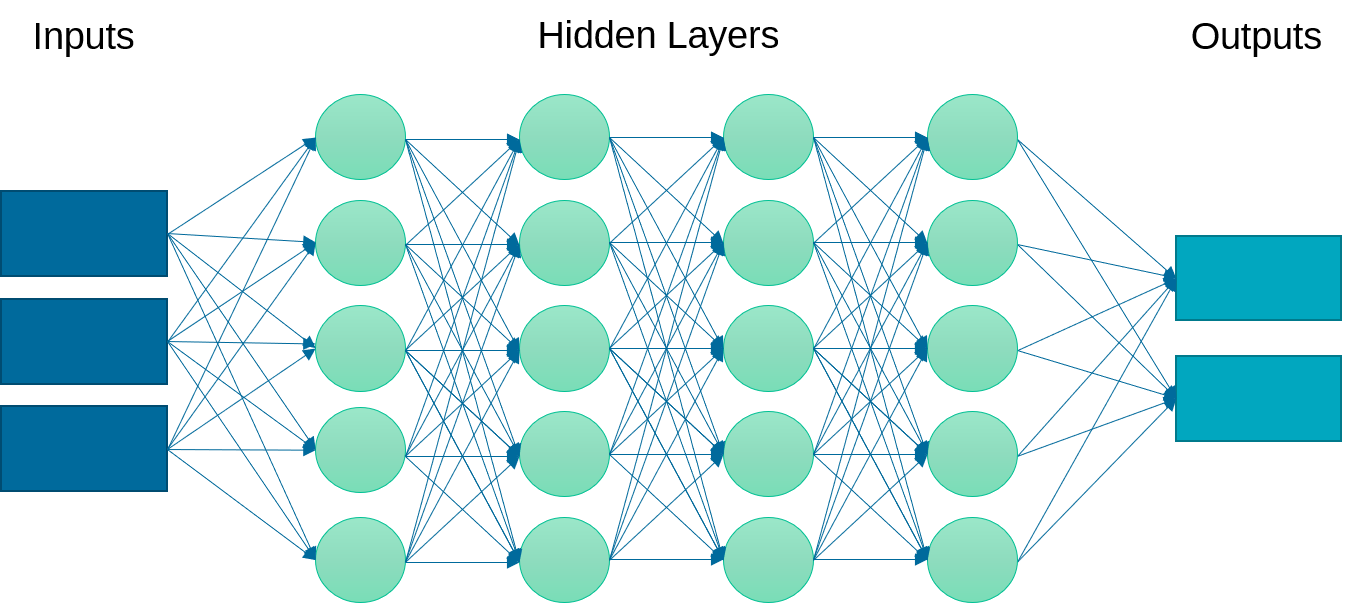


__Ein MLP (Multi-Layer Perceptron)__ wird mit zwei Arrays trainiert:

dem Array X der Größe (n_samples, n_features), das die Trainingsbeispiele als Fließkomma-Feature-Vektoren enthält, 

und dem Array y der Größe (n_samples,), das die Zielwerte (Klassenlabels) der Trainingsdaten enthält.

Ein MLP kann ein nichtlineares Modell an die Trainingsdaten anpassen.
clf.coefs_ enthält die Gewichtsmatrizen, die die Modellparameter darstellen.

Derzeit unterstützt der MLPClassifier ausschließlich die Cross-Entropy-Verlustfunktion, die Wahrscheinlichkeitsabschätzungen über die Methode predict_proba ermöglicht.

Das MLP wird mithilfe von Backpropagation trainiert. Genauer gesagt verwendet es eine Form des Gradientenabstiegs, wobei die Gradienten durch Backpropagation berechnet werden.

Für Klassifikationsaufgaben minimiert es die Cross-Entropy-Verlustfunktion und liefert einen Vektor von Wahrscheinlichkeitsabschätzungen.

Der MLPClassifier unterstützt Mehrklassen-Klassifikation, indem er die Softmax-Funktion als Ausgabefunktion verwendet. Darüber hinaus unterstützt das Modell auch Multi-Label-Klassifikation, bei der ein Datenpunkt mehreren Klassen gleichzeitig angehören kann.

Für jede Klasse wird die rohe Ausgabe durch die logistische Funktion (Sigmoid) transformiert.
Werte größer oder gleich 0,5 werden zu 1 gerundet, andernfalls zu 0.

Bei einer Vorhersage entsprechen die Indizes, bei denen der Wert 1 ist, den zugewiesenen Klassen dieses Datenpunkts.


In [27]:
from sklearn.neural_network import MLPClassifier

clf = MLPClassifier(solver='lbfgs',alpha=1e-5,max_iter=200,activation='relu',\
                    hidden_layer_sizes=(10,30,10), random_state=1, shuffle=True)
clf.fit(XA,yA)
yP = clf.predict(XB)
assess(yP)

![animal_eggs](https://apmonitor.com/che263/uploads/Begin_Python/animal_eggs.png)

### Unüberwachte Klassifikation

Weitere Beispiele zeigen das Potenzial des unüberwachten Lernens, um Gruppen zu klassifizieren. Unüberwachtes Lernen verwendet keine Labels (``True``/``False``), daher müssen die Ergebnisse möglicherweise angepasst werden, um mit dem Testdatensatz übereinzustimmen, z. B. mit
``if len(XB[yP!=yB]) > n/4: yP = 1 - yP``

![idea](https://apmonitor.com/che263/uploads/Begin_Python/idea.png)

### U.1 K-Means Clustering

**Definition**: Legt fest, wie viele mögliche Cluster (bzw. K) es im Datensatz gibt. Der Algorithmus verschiebt die K-Zentren iterativ und ordnet die Datenpunkte dem Cluster zu, dessen Zentrum am nächsten liegt.

__////Anmerkung: specify oder specifies?__
__original: Definition:  Specify how many possible clusters (or K) there are in the dataset. The algorithm then iteratively moves the K-centers and selects the datapoints that are closest to that centroid in the cluster.__

**Vorteile**: Der häufigste und einfachste Clustering-Algorithmus.

**Nachteile**: Die Anzahl der Cluster muss vorgegeben werden, kann jedoch in der Regel bestimmt werden, indem man die Clusterzahl erhöht, bis sich die Zielfunktion nicht mehr wesentlich ändert.

In [28]:
try:
    from sklearn.cluster import KMeans
    km = KMeans(n_clusters=2)
    km.fit(XA)
    yP = km.predict(XB)
    if len(XB[yP!=yB]) > n/4: yP = 1 - yP 
    assess(yP)
except:
    print('K-Means failed')

![idea](https://apmonitor.com/che263/uploads/Begin_Python/idea.png)

### U.2 Gaussian Mixture Model (Gaußsches Mischmodell)

**Definition**: Datenpunkte an Clustergrenzen können ähnliche Zugehörigkeitswahrscheinlichkeiten zu mehreren Clustern haben. Ein Mischmodell sagt daher Wahrscheinlichkeiten voraus (statt einer harten Zuordnung wie beim K-Means-Clustering).

**Vorteile**: Bezieht Unsicherheit in die Lösung mit ein.

**Nachteile**: Unsicherheit ist für manche Anwendungen unerwünscht. Diese Methode ist für Clustering weniger gebräuchlich als K-Means.


In [29]:
from sklearn.mixture import GaussianMixture
gmm = GaussianMixture(n_components=2)
gmm.fit(XA)
yP = gmm.predict_proba(XB) # liefert Wahrscheinlichkeiten
if len(XB[np.round(yP[:,0])!=yB]) > n/4: yP = 1 - yP 
assess(np.round(yP[:,0]))

![idea](https://apmonitor.com/che263/uploads/Begin_Python/idea.png)

### U.3 Spektrales Clustering

**Definition**: Spektrales Clustering wird auch als segmentierungsbasierte Objektkategorisierung bezeichnet. Die Methode hat Wurzeln in der Graphentheorie: Gemeinschaften von Knoten werden über die Kanten identifiziert, die sie verbinden. Das Verfahren ist flexibel und erlaubt auch das Clustern von Nicht-Graph-Daten. Es nutzt Informationen aus den Eigenwerten spezieller Matrizen, die aus dem Graphen bzw. dem Datensatz gebildet werden.

__/////Anm.: verständlicher formulieren?__

**Vorteile**: Flexibler Ansatz zum Finden von Clustern, wenn die Daten die Voraussetzungen anderer gängiger Algorithmen nicht erfüllen.

**Nachteile**: Bei großen Graphen ist der zweite Eigenwert der (normalisierten) Graph-Laplacematrix oft schlecht konditioniert, was zu langsamer Konvergenz iterativer Eigenwertlöser führt. Spektrales Clustering ist rechnerisch teuer, sofern der Graph nicht dünn besetzt ist und sich die Ähnlichkeitsmatrix nicht effizient konstruieren lässt.

In [30]:
from sklearn.cluster import SpectralClustering
sc = SpectralClustering(n_clusters=2,eigen_solver='arpack',\
                        affinity='nearest_neighbors')
yP = sc.fit_predict(XB) # Keine Trennung zwischen fit- und predict-Aufrufen
                        # Muss auf demselben Datensatz trainieren (fit) und vorhersagen (predict)
if len(XB[yP!=yB]) > n/4: yP = 1 - yP 
assess(yP)

![expert](https://apmonitor.com/che263/uploads/Begin_Python/expert.png)

### TCLab-Übung

Trainiere einen Klassifikator, der vorhersagt, ob der Heizer ein (100 %) oder aus (0 %) ist. Erzeuge Daten über 10 Minuten mit 1-Sekunden-Abtastung. Wenn du kein TCLab hast, verwende einen der Beispieldatensätze.

- [Beispieldatensatz 1 (10 min)](http://apmonitor.com/do/uploads/Main/tclab_data5.txt): http://apmonitor.com/do/uploads/Main/tclab_data5.txt 
- [Beispieldatensatz 2 (60 min)](http://apmonitor.com/do/uploads/Main/tclab_data6.txt): http://apmonitor.com/do/uploads/Main/tclab_data6.txt

In [31]:
# 10-minütige Datenerfassung
import tclab, time
import numpy as np
import pandas as pd
with tclab.TCLab() as lab:
    n = 600; on=100; t = np.linspace(0,n-1,n)        
    Q1 = np.zeros(n); T1 = np.zeros(n)
    Q2 = np.zeros(n); T2 = np.zeros(n)    
    Q1[20:41]=on; Q1[60:91]=on; Q1[150:181]=on
    Q1[190:206]=on; Q1[220:251]=on; Q1[260:291]=on
    Q1[300:316]=on; Q1[340:351]=on; Q1[400:431]=on
    Q1[500:521]=on; Q1[540:571]=on; Q1[20:41]=on
    Q1[60:91]=on; Q1[150:181]=on; Q1[190:206]=on
    Q1[220:251]=on; Q1[260:291]=on
    print('Time Q1 Q2 T1   T2')
    for i in range(n):
        T1[i] = lab.T1; T2[i] = lab.T2
        lab.Q1(Q1[i])
        if i%5==0:
            print(int(t[i]),Q1[i],Q2[i],T1[i],T2[i])
        time.sleep(1)
data = np.column_stack((t,Q1,Q2,T1,T2))
data8 = pd.DataFrame(data,columns=['Time','Q1','Q2','T1','T2'])
data8.to_csv('08-tclab.csv',index=False)

TCLab version 1.0.0
Arduino Leonardo connected on port COM4 at 115200 baud.
TCLab Firmware 2.0.1 Arduino Leonardo/Micro.
Time Q1 Q2 T1   T2
0 0.0 0.0 23.477 23.509
5 0.0 0.0 23.477 23.541
10 0.0 0.0 23.477 23.509
15 0.0 0.0 23.477 23.541
20 100.0 0.0 23.477 23.541
25 100.0 0.0 23.477 23.605
30 100.0 0.0 23.799 23.638
35 100.0 0.0 24.443 23.767
40 100.0 0.0 25.442 23.799
45 0.0 0.0 26.699 23.863
50 0.0 0.0 27.666 24.121
55 0.0 0.0 28.536 24.153
60 100.0 0.0 29.277 24.443
65 100.0 0.0 29.857 24.733
70 100.0 0.0 30.566 24.895
75 100.0 0.0 31.533 25.152
80 100.0 0.0 32.5 25.442
85 100.0 0.0 33.789 25.765
90 100.0 0.0 35.271 26.151
95 0.0 0.0 36.689 26.699
100 0.0 0.0 37.785 27.021
105 0.0 0.0 38.655 27.344
110 0.0 0.0 39.268 27.666
115 0.0 0.0 39.912 28.053
120 0.0 0.0 39.912 28.504
125 0.0 0.0 40.073 28.794
130 0.0 0.0 39.912 29.084
135 0.0 0.0 39.912 29.277
140 0.0 0.0 39.59 29.6
145 0.0 0.0 39.268 29.6
150 100.0 0.0 38.945 29.922
155 100.0 0.0 38.623 29.954
160 100.0 0.0 38.623 30.244
1

Verwende die Datei ``08-tclab.csv``, um den Klassifikator zu trainieren und zu testen. Wähle die Features der Daten aus und skaliere sie auf 0–1, einschließlich ``T1``, ``T2`` sowie der 1. und 2. Ableitung von ``T1``. Nutze die gemessenen Temperaturen, die Ableitungen und das Heizer-Label zur Erstellung eines Klassifikators, der vorhersagt, wann der Heizer ein oder aus ist. Validiere den Klassifikator mit neuen Daten, die nicht zum Training verwendet wurden. Der Ausgangscode ist unten angegeben, enthält jedoch ``T2`` nicht als Eingabe-Feature. 

Füge ``T2`` als Eingabe-Feature zum Klassifikator hinzu. Verbessert dies die Leistung des Klassifikators?

C:\Users\E-Maker\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:546: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)
C:\Users\E-Maker\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\E-Maker\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Use

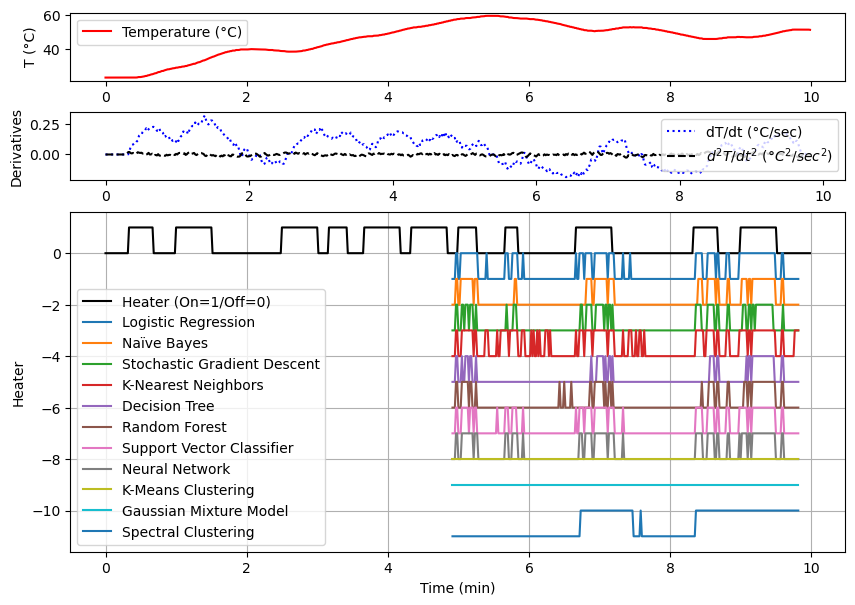

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import gridspec
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split

try:
    data = pd.read_csv('08-tclab.csv')
except:
    print('Warning: Unable to load 08-tclab.csv, using online data')
    url = 'http://apmonitor.com/do/uploads/Main/tclab_data5.txt'
    data = pd.read_csv(url)

# Eingabefeatures: Temperatur sowie 1. und 2. Ableitung
# Kubischer Polynomial-Fit der Temperatur mit 10 Datenpunkten
data["dT1"] = np.nan
data["d2T1"] = np.nan

for i in range(len(data)):
    if i < len(data) - 10:
        # 10 Punkte ab i (positionsbasiert!)
        x = data.iloc[i:i+10]["Time"].values - data.iloc[i]["Time"]
        y_fit = data.iloc[i:i+10]["T1"].values
        p = np.polyfit(x, y_fit, 3)

        # Werte die Ableitungen am Mittelpunkt (bei 5 s) aus.
        t = 5.0
        data.loc[i, "dT1"] = 3.0*p[0]*t**2 + 2.0*p[1]*t + p[2]
        data.loc[i, "d2T1"] = 6.0*p[0]*t + 2.0*p[1]
    # else bleibt NaN (wie im Original)

# Entferne die letzten zehn Werte (weil dort NaN in den Ableitungen stehen)
X = data.iloc[:-10][["T1", "dT1", "d2T1"]].to_numpy()
y = data.iloc[:-10]["Q1"].to_numpy()

# Sicherheitscheck: falls doch NaNs drin sind (z.B. am Ende), entfernen
mask = np.isfinite(X).all(axis=1)
X = X[mask]
y = y[mask]

# Daten skalieren (Input-Features)
s1 = MinMaxScaler(feature_range=(0, 1))
Xs = s1.fit_transform(X)

# Ausgabe-Labels (Heizer an / aus) als Boolean-Vektor
ys = (y > 50.0)

# Aufteilung in Trainings- und Testteilmengen (jeweils 50 %)
XA, XB, yA, yB = train_test_split(Xs, ys, test_size=0.5, shuffle=False)

# Überwachte Klassifikation
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import SGDClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier

lr = LogisticRegression(solver='lbfgs')
nb = GaussianNB()
sgd = SGDClassifier(loss='modified_huber', shuffle=True, random_state=101)
knn = KNeighborsClassifier(n_neighbors=5)
dtree = DecisionTreeClassifier(max_depth=10, random_state=101,
                               max_features=None, min_samples_leaf=5)
rfm = RandomForestClassifier(n_estimators=70, oob_score=True, n_jobs=1,
                             random_state=101, max_features=None,
                             min_samples_leaf=3)
svm = SVC(gamma='scale', C=1.0)
clf = MLPClassifier(solver='lbfgs', alpha=1e-5, max_iter=200,
                    activation='relu', hidden_layer_sizes=(10, 30, 10),
                    random_state=1, shuffle=True)

models = [lr, nb, sgd, knn, dtree, rfm, svm, clf]

# Überwachtes Lernen
yP = [None] * (len(models) + 3)  # +3 für unüberwachtes Lernen
for i, m in enumerate(models):
    m.fit(XA, yA)
    yP[i] = m.predict(XB).astype(int)  # für Plot als 0/1

# Unüberwachtes Lernen
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn.cluster import SpectralClustering

km = KMeans(n_clusters=2, random_state=101)
gmm = GaussianMixture(n_components=2, random_state=101)
sc = SpectralClustering(n_clusters=2, eigen_solver='arpack',
                        affinity='nearest_neighbors')

km.fit(XA)
yP[8] = km.predict(XB).astype(int)

gmm.fit(XA)
yP[9] = gmm.predict(XB).astype(int)

yP[10] = sc.fit_predict(XB).astype(int)

# Plot
plt.figure(figsize=(10, 7))
gs = gridspec.GridSpec(3, 1, height_ratios=[1, 1, 5])

plt.subplot(gs[0])
plt.plot(data["Time"] / 60, data["T1"], "r-", label="Temperature (°C)")
plt.ylabel("T (°C)")
plt.legend()

plt.subplot(gs[1])
plt.plot(data["Time"] / 60, data["dT1"], "b:", label="dT/dt (°C/sec)")
plt.plot(data["Time"] / 60, data["d2T1"], "k--",
         label=r"$d^2T/dt^2$ ($°C^2/sec^2$)")
plt.ylabel("Derivatives")
plt.legend()

plt.subplot(gs[2])
plt.plot(data["Time"] / 60, data["Q1"] / 100, "k-", label="Heater (On=1/Off=0)")

# Zeitachse passend zur Testmenge (XB)
t2 = data.iloc[-10-len(XB):-10]["Time"].values  # exakt Länge von XB

desc = ["Logistic Regression", "Naïve Bayes", "Stochastic Gradient Descent",
        "K-Nearest Neighbors", "Decision Tree", "Random Forest",
        "Support Vector Classifier", "Neural Network",
        "K-Means Clustering", "Gaussian Mixture Model", "Spectral Clustering"]

for i in range(11):
    plt.plot(t2 / 60, yP[i] - i - 1, label=desc[i])

plt.ylabel("Heater")
plt.xlabel("Time (min)")
plt.grid(True)
plt.legend()
plt.show()